# 02 · The MultiHop benchmark: what a record is scored against

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 2 of 8**

You take apart a benchmark record, measure which question types break a single retrieval, and build the pipeline that manufactures an eval set from a corpus that has no labels.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 01. | Notebook 03, which changes the index and measures the difference on this set. |

The mini benchmark here has 12 questions over 30 fictional documents. The real MultiHop-RAG set has 2,556 queries over a news corpus (Tang and Yang, COLM 2024), and a gated loader for it sits at the end.

## Where this sits on the pipeline

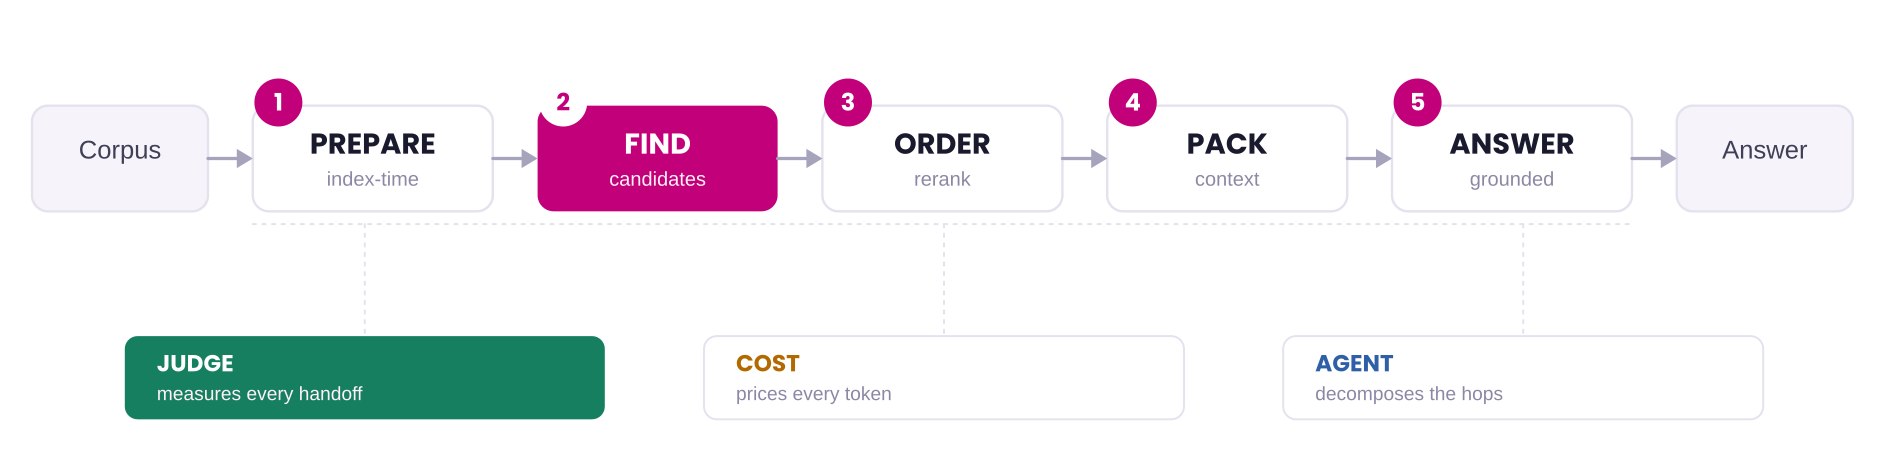

*Still FIND and JUDGE, now grounded in a labelled set.*

## 1 · A benchmark record, and what each field is scored against

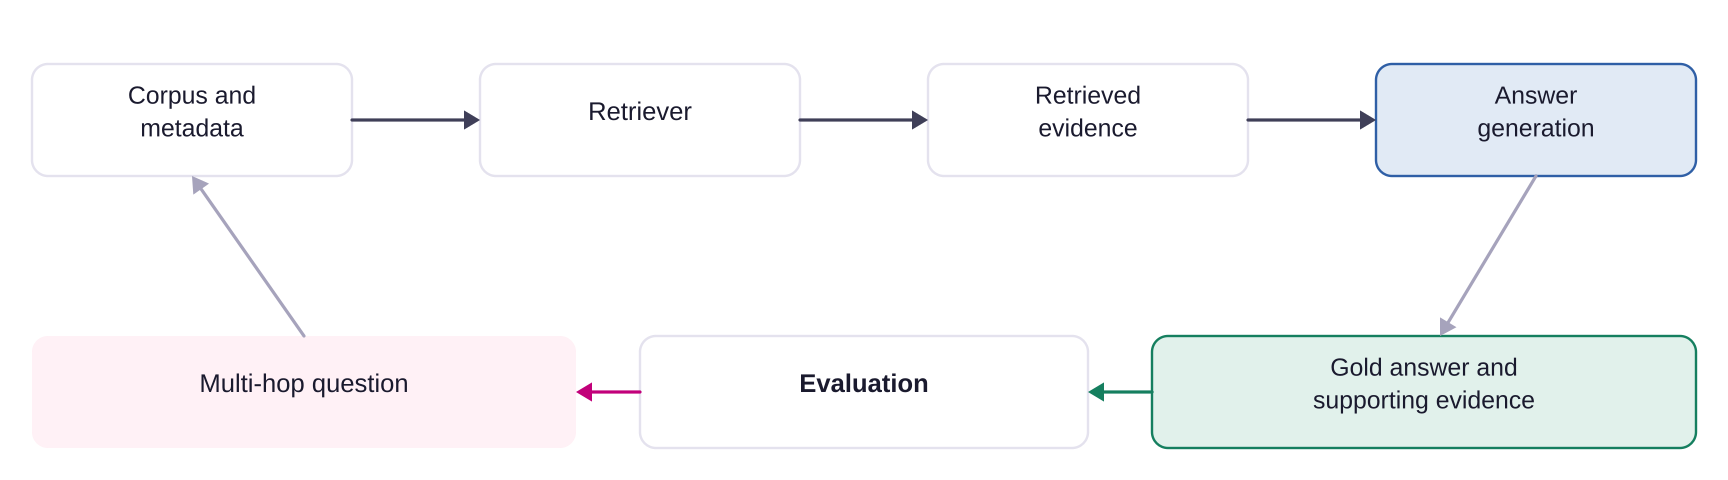

*Established idea. The record carries both references.*

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
import json
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
q = rk.ANCHOR
record = {"qid": q.qid, "question_type": q.qtype, "query": q.text, "answer": q.answer, "dependent": q.dependent, "frozen": q.frozen,
          "evidence": [{"doc_id": d, "source": store.doc(d).source, "date": store.doc(d).date, "span": s[:60] + "..."} for d, s in q.gold]}
print(json.dumps(record, indent=2))
table(pd.DataFrame([
    ("query", "the text the retriever and the generator see", "nothing, it is the input"),
    ("answer", "the gold answer, None for a null question", "correctness of the generated answer, or a correct abstention"),
    ("evidence[].doc_id and span", "the exact sentence in the exact document that carries each required fact", "retrieval recall at chunk level, context coverage, and span support for faithfulness"),
    ("evidence[].source and date", "provenance and metadata", "citation accuracy and metadata filters"),
    ("question_type", "inference, comparison, temporal or null", "per-type slicing, and the abstention score on null"),
    ("dependent", "whether hop two needs hop one's answer", "the single-shot against agentic decision in notebook 08"),
    ("frozen", "held out from every tuning run", "the release gate in notebook 06"),
], columns=["field", "what it holds", "what it is scored against"]), "One record, seven fields, each with a job in the evaluation")

{
  "qid": "q01",
  "question_type": "inference",
  "query": "The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public, and in what year?",
  "answer": "Vega Dynamics, 2023",
  "dependent": true,
  "frozen": false,
  "evidence": [
    {
      "doc_id": "a1",
      "source": "TechCrunch",
      "date": "2026-03-12",
      "span": "named Elena Ruiz as chief executive on Thursday, ending a ni..."
    },
    {
      "doc_id": "b7",
      "source": "Reuters",
      "date": "2023-06-08",
      "span": "Shares of Vega Dynamics rose 28 percent in their Nasdaq debu..."
    }
  ]
}


field,what it holds,what it is scored against
query,the text the retriever and the generator see,"nothing, it is the input"
answer,"the gold answer, None for a null question","correctness of the generated answer, or a correct abstention"
evidence[].doc_id and span,the exact sentence in the exact document that carries each required fact,"retrieval recall at chunk level, context coverage, and span support for faithfulness"
evidence[].source and date,provenance and metadata,citation accuracy and metadata filters
question_type,"inference, comparison, temporal or null","per-type slicing, and the abstention score on null"
dependent,whether hop two needs hop one's answer,the single-shot against agentic decision in notebook 08
frozen,held out from every tuning run,the release gate in notebook 06


## 2 · Put the benchmark next to the corpus

The questions live in the same in-memory database as the documents, so a metric is a join, not a script.

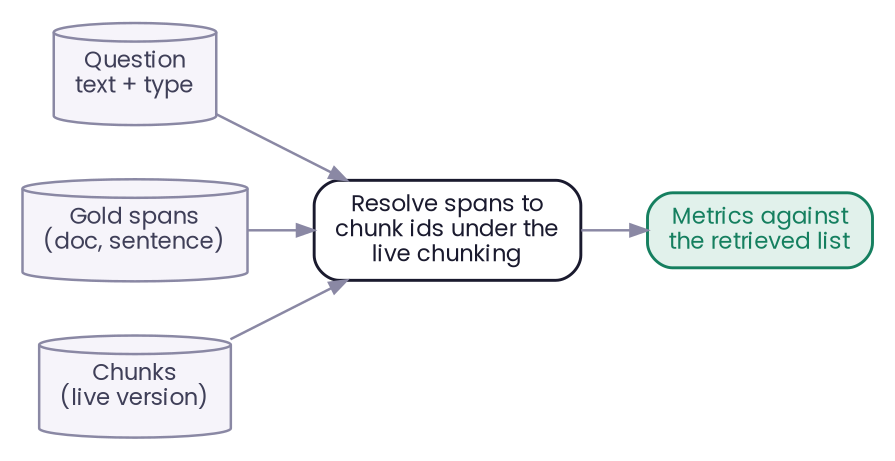

*Gold is stored at sentence level and resolved to chunk ids at run time, so the same benchmark scores every chunking strategy.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    q[("Question<br/>text + type")]
    g[("Gold spans<br/>(doc, sentence)")]
    r["Resolve spans to<br/>chunk ids under the<br/>live chunking"]
    m["Metrics against<br/>the retrieved list"]
    c[("Chunks<br/>(live version)")]
    q --> r
    g --> r
    c --> r
    r --> m
    class q data
    class g data
    class m ok
    class c data
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [3]:
store.con.executescript("""
CREATE TABLE IF NOT EXISTS benchmark (qid TEXT PRIMARY KEY, qtype TEXT, question TEXT, answer TEXT, dependent INTEGER, frozen INTEGER);
CREATE TABLE IF NOT EXISTS gold (qid TEXT, doc_id TEXT, span TEXT);
""")
store.con.executemany("INSERT OR REPLACE INTO benchmark VALUES (?,?,?,?,?,?)", [(q.qid, q.qtype, q.text, q.answer, int(q.dependent), int(q.frozen)) for q in questions])
store.con.executemany("INSERT INTO gold VALUES (?,?,?)", [(q.qid, d, s) for q in questions for d, s in q.gold])
store.con.commit()
display(table(store.sql("SELECT qtype, COUNT(*) AS questions, SUM(dependent) AS dependent, SUM(frozen) AS frozen FROM benchmark GROUP BY qtype"), "The benchmark by type"))
table(store.sql("""SELECT b.qid, b.qtype, g.doc_id, d.source, d.date, substr(g.span, 1, 60) || '...' AS span
                   FROM benchmark b JOIN gold g ON g.qid = b.qid JOIN docs d ON d.doc_id = g.doc_id WHERE b.qid IN ('q01','q04','q10') ORDER BY b.qid"""),
      "Gold evidence joined to document metadata. q10 is a null question and has no gold rows.")

qtype,questions,dependent,frozen
comparison,3,0,0
inference,3,3,0
null,3,0,1
temporal,3,0,2


qid,qtype,doc_id,source,date,span
q01,inference,a1,TechCrunch,2026-03-12,"named Elena Ruiz as chief executive on Thursday, ending a ni..."
q01,inference,b7,Reuters,2023-06-08,Shares of Vega Dynamics rose 28 percent in their Nasdaq debu...
q04,comparison,o1,Reuters,2021-10-14,Orbis Networks raised 500 million dollars in its initial pub...
q04,comparison,b7,Reuters,2023-06-08,The initial public offering raised 310 million dollars...


## 3 · Four question types, and what each one stresses

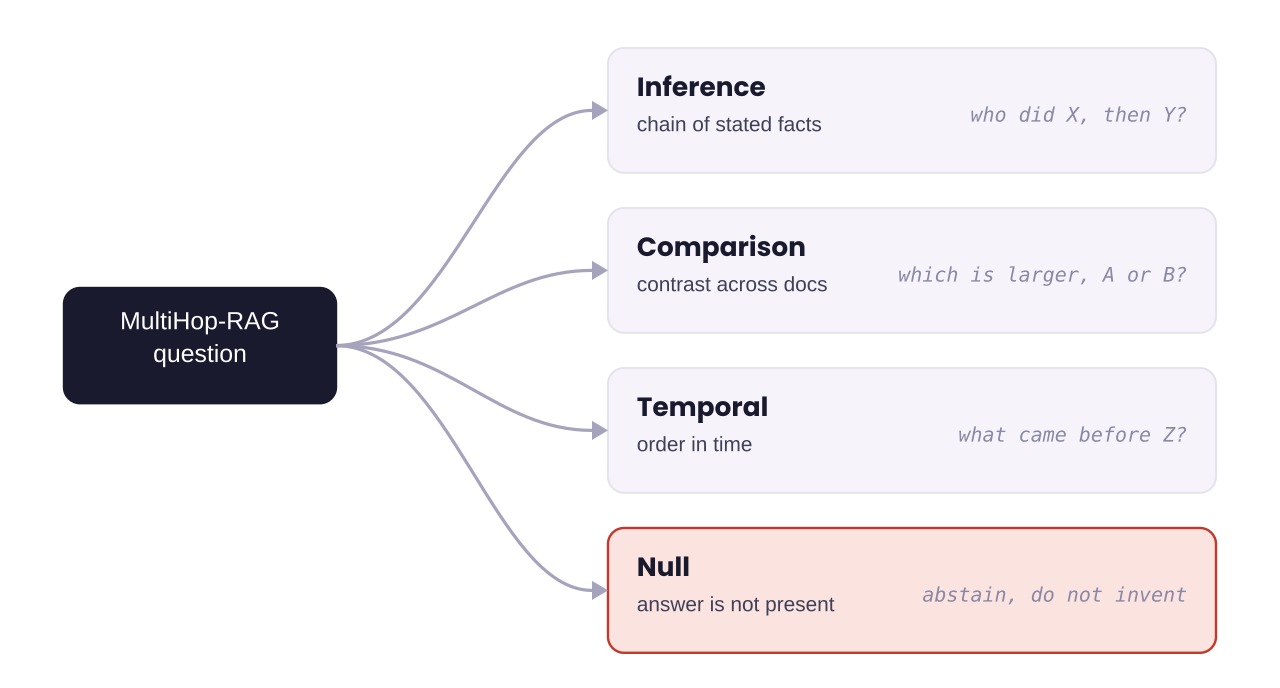

*The four types of MultiHop-RAG, own drawing.*

mode,type,full_chain,correct,abstained
dense,comparison,1.000,1.000,0.000
dense,inference,0.330,0.330,0.670
dense,null,nan,1.000,1.000
dense,temporal,1.000,1.000,0.000
hybrid,comparison,1.000,1.000,0.000
hybrid,inference,0.330,0.330,0.670
hybrid,null,nan,1.000,1.000
hybrid,temporal,1.000,1.000,0.000


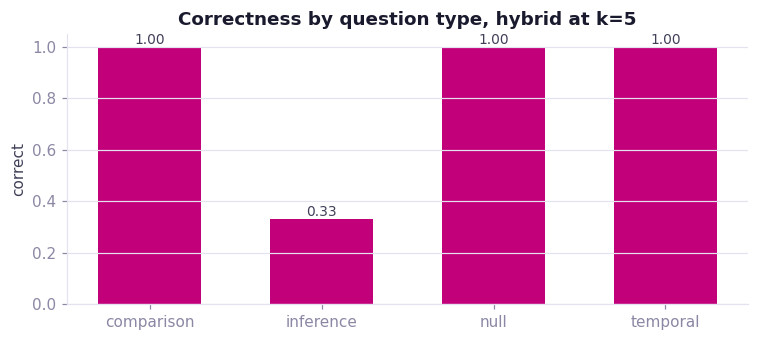

In [4]:
frames = []
for mode in ["dense", "hybrid"]:
    df = rk.run_benchmark(rk.RunConfig(f"{mode}_k5", mode=mode, n_pool=50, k=5), retriever, generator, questions, chunks)
    g = df.groupby("type").agg(full_chain=("full_chain@k", "mean"), correct=("correct", "mean"), abstained=("abstained", "mean")).round(2)
    g["mode"] = mode
    frames.append(g.reset_index())
by_type = pd.concat(frames)[["mode", "type", "full_chain", "correct", "abstained"]]
display(table(by_type, "Per-type results at k=5. Retrieval columns are NaN for null questions, which have no gold."))
piv = by_type.pivot(index="type", columns="mode", values="correct")
bars(list(piv.index), list(piv["hybrid"]), "Correctness by question type, hybrid at k=5", "correct", fmt="{:.2f}")

| Question type | What it stresses | Retrieval strategy the type implies | Where a single retrieval breaks |
|---|---|---|---|
| Inference (bridge entity) | A chain: the second fact can only be searched once the first is known. | Decompose, then retrieve per hop and carry the bridge entity forward. | Hop two never enters the pool because the query text does not mention it. |
| Comparison | Two independent facts about two named entities. | Two parallel retrievals, one per entity, fused by rank. | One entity's evidence crowds the other out of the top k. |
| Temporal | Two dated events and their order. | Retrieve both, then read the dates from metadata rather than from prose. | An undated or interim event outranks the dated one. |
| Null | The discipline to say the corpus does not contain it. | Retrieve, then let the abstention rule fire when no span supports an answer. | A near-miss document (a CFO of another firm) tempts a fabrication. |

Established as the four types of the MultiHop-RAG paper; the strategy column is a construction from the advanced-track deck. The runner below executes the mapping.

In [5]:
STRATEGY = {"inference": "decompose and chain hops", "comparison": "parallel retrieval per entity, then fuse", "temporal": "retrieve both, order by metadata date", "null": "retrieve, then abstain when no span supports an answer"}
rows = [{"qid": q.qid, "type": q.qtype, "dependent": q.dependent, "strategy the type implies": STRATEGY[q.qtype]} for q in questions]
table(pd.DataFrame(rows), "Strategy per question, executed from the type field")

qid,type,dependent,strategy the type implies
q01,inference,True,decompose and chain hops
q02,inference,True,decompose and chain hops
q03,inference,True,decompose and chain hops
q04,comparison,False,"parallel retrieval per entity, then fuse"
q05,comparison,False,"parallel retrieval per entity, then fuse"
q06,comparison,False,"parallel retrieval per entity, then fuse"
q07,temporal,False,"retrieve both, order by metadata date"
q08,temporal,False,"retrieve both, order by metadata date"
q09,temporal,False,"retrieve both, order by metadata date"
q10,null,False,"retrieve, then abstain when no span supports an answer"


## 4 · Dependent hops against independent hops, measured

Whether a question needs an agent is a property you can measure: retrieve with the question text alone and look at the rank of each gold span. If one span is reachable and the other is not, hop two depends on hop one.

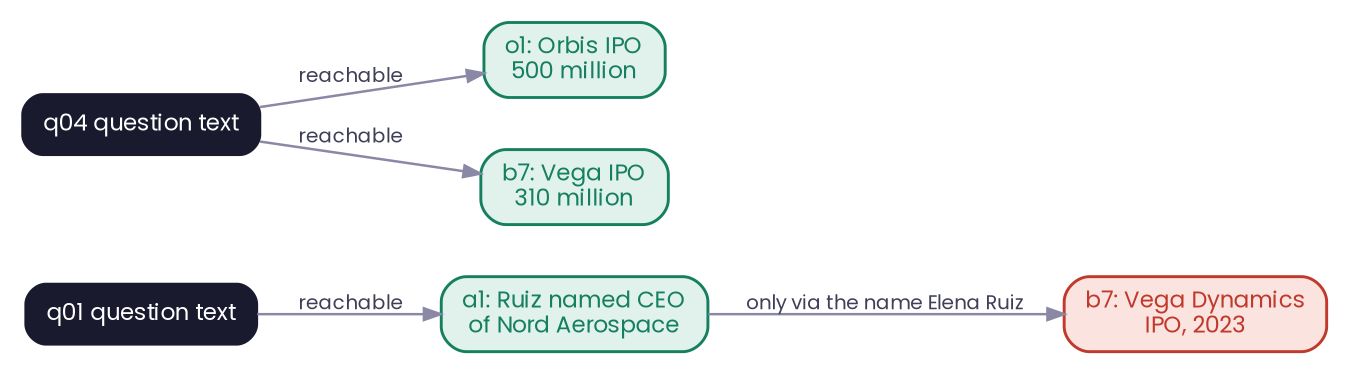

*q01 is a chain; q04 is two independent lookups. The cell below measures the same thing for every question.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    q1(["q01 question text"])
    h1["a1: Ruiz named CEO<br/>of Nord Aerospace"]
    h2["b7: Vega Dynamics<br/>IPO, 2023"]
    q4(["q04 question text"])
    o1["o1: Orbis IPO<br/>500 million"]
    b7["b7: Vega IPO<br/>310 million"]
    q1 -->|reachable| h1
    h1 -->|only via the name Elena Ruiz| h2
    q4 -->|reachable| o1
    q4 -->|reachable| b7
    class q1 start
    class h1 ok
    class h2 fail
    class q4 start
    class o1 ok
    class b7 ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [6]:
rows = []
for q in [x for x in questions if x.gold]:
    ids = [cid for cid, _ in retriever.hybrid(q.text, k=64)]
    ranks = []
    for s in rk.gold_chunk_sets(q, chunks):
        r = min((ids.index(c) + 1 for c in s if c in ids), default=None)
        ranks.append(r)
    rows.append({"qid": q.qid, "type": q.qtype, "declared dependent": q.dependent,
                 "rank of span 1": ranks[0], "rank of span 2": ranks[1], "worst rank": max(r for r in ranks if r is not None)})
dep = pd.DataFrame(rows)
table(dep.sort_values("worst rank", ascending=False), "Rank of each gold chunk when retrieving with the question text alone, hybrid over all 64 chunks")

qid,type,declared dependent,rank of span 1,rank of span 2,worst rank
q01,inference,True,7,19,19
q03,inference,True,1,9,9
q08,temporal,False,1,4,4
q09,temporal,False,3,1,3
q02,inference,True,1,2,2
q05,comparison,False,1,2,2
q04,comparison,False,1,2,2
q07,temporal,False,2,1,2
q06,comparison,False,1,2,2


| If, retrieving from the question text alone | Then | Because |
|---|---|---|
| Every gold span ranks inside a modest pool, as the comparison and temporal questions do. | A single hybrid retrieval with a wide enough N will carry the chain into the pool. | The question text already names both entities. |
| One span ranks far down or not at all, as the inference questions do. | Hop two depends on hop one, and a loop that carries the bridge entity forward is needed. Notebook 08. | The second entity is not in the question, so no encoding of the question can reach it. |
| The declared `dependent` flag and the measured ranks disagree, as q02 does above with both spans at ranks 1 and 2. | Separate logical dependency from retrieval dependency. q02 is logically two hops, but the question leaks hop-two vocabulary (Series B, led by a venture firm), so a wide single retrieval reaches both spans. The loop is still what proves the Series B belongs to the acquired company. | A label is a claim about the question, and the retrieval trace is the evidence. Measure it per question rather than assuming it from the type. |

## 5 · Manufacturing an evaluation set from a corpus that has no labels

Clients never hand you gold labels. This pipeline builds them from the corpus, and the human-review step is the only part that makes the set defensible.

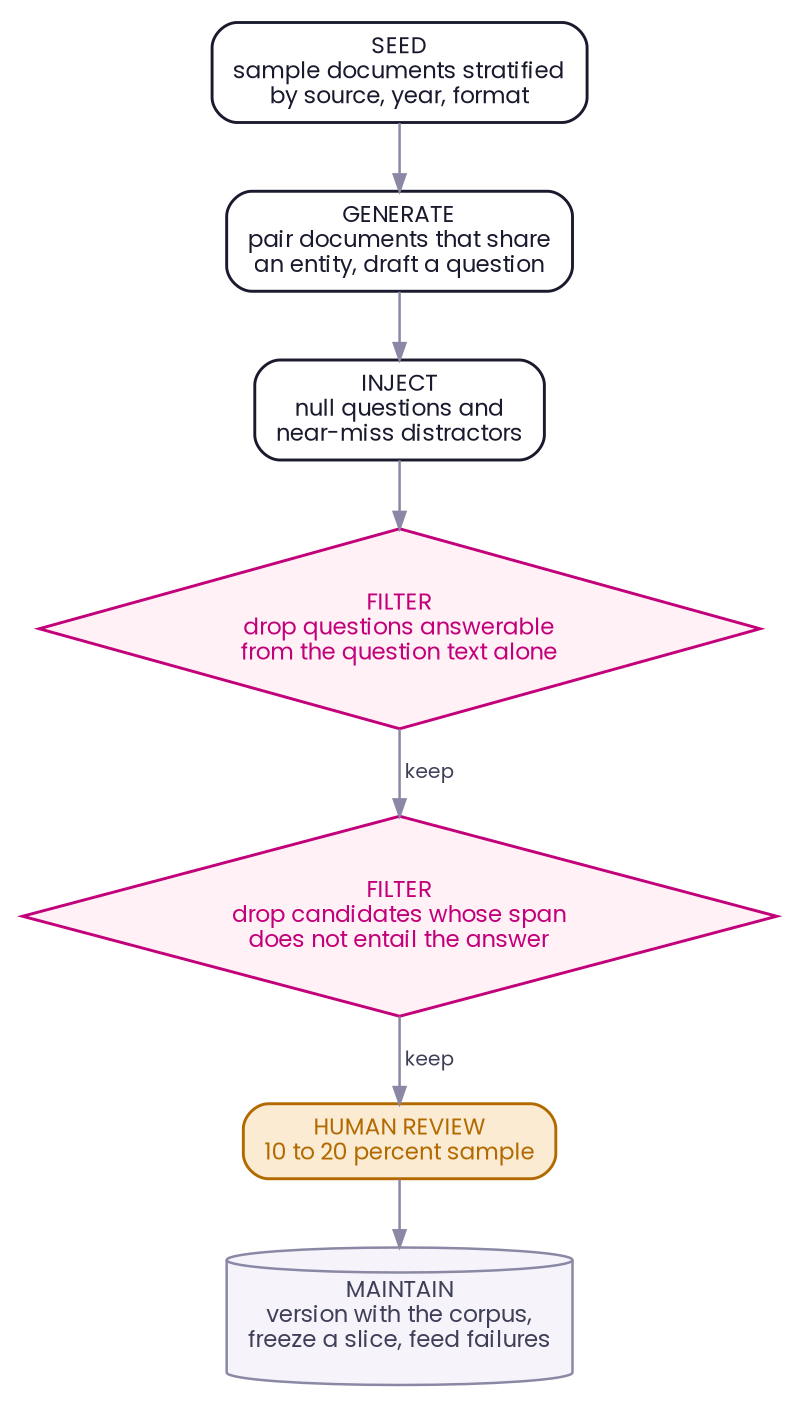

*The pipeline from the advanced-track deck, as code. A generated set inherits its generator's blind spots; the frozen slice and the production-failure feed are what stop it becoming a mirror of your own retriever.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    seed["SEED<br/>sample documents stratified<br/>by source, year, format"]
    gen["GENERATE<br/>pair documents that share<br/>an entity, draft a question"]
    inj["INJECT<br/>null questions and<br/>near-miss distractors"]
    f1{"FILTER<br/>drop questions answerable<br/>from the question text alone"}
    f2{"FILTER<br/>drop candidates whose span<br/>does not entail the answer"}
    rev["HUMAN REVIEW<br/>10 to 20 percent sample"]
    ver[("MAINTAIN<br/>version with the corpus,<br/>freeze a slice, feed failures")]
    seed --> gen
    gen --> inj
    inj --> f1
    f1 -->|keep| f2
    f2 -->|keep| rev
    rev --> ver
    class f1 dec
    class f2 dec
    class rev cost
    class ver data
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [7]:
import re, hashlib
docs = store.docs()

# SEED: stratify by source and year so the set is not dominated by one outlet or one period
strata = pd.DataFrame([{"doc_id": d.doc_id, "source": d.source, "year": d.date[:4]} for d in docs])
display(table(strata.groupby(["source", "year"]).size().reset_index(name="docs").sort_values(["source", "year"]), "SEED: the corpus by source and year"))

# GENERATE: pair documents that share a named entity. Entities here are capitalised token runs, a deliberately simple extractor.
def entities(text):
    cands = re.findall(r"(?:[A-Z][a-z]+(?:-[A-Z]?[a-z]+)?\s?){2,}", text)
    return {c.strip() for c in cands if c.strip().split()[0] not in {"The", "Shares", "Chief", "Before", "Version", "Known", "Nasdaq", "European", "Venture", "Markets", "Interim", "Bankers", "Late", "Halden", "Ruiz", "Lin", "Weber", "Sadeghi", "Natarajan", "Kestrel"} or c.strip() in {"Halden Robotics", "Kestrel Foods"}}
ent_docs = {}
for d in docs:
    for e in entities(d.body):
        ent_docs.setdefault(e, set()).add(d.doc_id)
pairs = [(e, sorted(ds)) for e, ds in ent_docs.items() if len(ds) >= 2]
display(table(pd.DataFrame([{"bridge entity": e, "documents sharing it": ", ".join(ds), "candidate multi-hop pairs": len(ds) * (len(ds) - 1) // 2} for e, ds in sorted(pairs, key=lambda x: -len(x[1]))]).head(10),
              "GENERATE: entities that bridge two or more documents are where multi-hop questions come from"))

source,year,docs
Bloomberg,2024,1
Bloomberg,2025,4
Bloomberg,2026,2
Financial Times,2024,1
Financial Times,2025,2
Financial Times,2026,4
Halden Robotics engineering,2025,1
Reuters,2021,1
Reuters,2023,1
Reuters,2024,4


bridge entity,documents sharing it,candidate multi-hop pairs
Vega Dynamics,"a1, b7, e2, g3, s3",10
Orbis Networks,"d3, h3, o1, o2, o3",10
Elena Ruiz,"a1, b7, e2, g2",6
Lumen Bio,"l1, l2, l3, r1",6
Sable Energy,"n1, s1, s2, s3",6
Nord Aerospace,"a1, g1, g2",3
Halden Robotics,"h1, h3, h4",3
Brisk Automation,"h1, h2, n1",3
Northlight Ventures,"h2, n1, s1",3
Kestrel Foods,"k1, k2, k3",3


In [8]:
# INJECT: a null question is an entity plus an attribute the corpus never states about it. The near miss is a document that states that attribute for a different entity.
# each attribute: a question template, the pattern that would state it, and the pattern a near-miss document carries
attributes = {
    "cfo":      ("Who is the chief financial officer of {c}?", r"chief financial officer", r"chief financial officer"),
    "revenue":  ("What was the revenue of {c} in 2025?", r"reported .*revenue", r"reported .*revenue"),
    "underwriter": ("Which bank underwrote the initial public offering of {c}?", r"underwr", r"initial public offering"),
}
null_candidates = []
for company in ["Nord Aerospace", "Vela Systems", "Vega Dynamics", "Sable Energy"]:
    for key, (template, stated_pat, near_pat) in attributes.items():
        stated = any(company in d.body and re.search(stated_pat, d.body) for d in docs)
        near_miss = [d.doc_id for d in docs if re.search(near_pat, d.body) and (company in d.body or key != "underwriter" or True)]
        if not stated:
            null_candidates.append({"candidate null question": template.format(c=company), "near-miss documents": ", ".join(near_miss[:4]) or "none"})
display(table(pd.DataFrame(null_candidates), "INJECT: null questions with a named near-miss distractor"))

# FILTER 1: drop questions answerable from the question text alone (the gold facts are already in the question)
def answerable_from_text(q):
    qt = set(rk.tokenize(q.text)); spans = set().union(*[set(rk.tokenize(s)) for _, s in q.gold]) if q.gold else set()
    return len(spans) > 0 and len(spans - qt) / len(spans) < 0.35
# FILTER 2: drop candidates whose gold spans do not entail the answer (answer tokens must appear across the spans)
def spans_entail(q):
    if q.answer is None: return True
    ans = set(rk.tokenize(q.answer)) - {"against", "before", "after", "yes", "no", "in", "dollars", "million", "billion"}
    span_toks = set().union(*[set(rk.tokenize(s)) for _, s in q.gold])
    return len(ans & span_toks) / max(1, len(ans)) >= 0.5
filt = pd.DataFrame([{"qid": q.qid, "type": q.qtype, "answerable from text alone": answerable_from_text(q), "spans entail answer": spans_entail(q)} for q in questions])
filt["keep"] = (~filt["answerable from text alone"]) & filt["spans entail answer"]
display(verdict_style(filt.assign(verdict=np.where(filt["keep"], "yes", "no")), "verdict"))

candidate null question,near-miss documents
Who is the chief financial officer of Nord Aerospace?,"h3, k2"
Which bank underwrote the initial public offering of Nord Aerospace?,"b7, f3, l1, o1"
Who is the chief financial officer of Vela Systems?,"h3, k2"
What was the revenue of Vela Systems in 2025?,"a1, e2, h4, k3"
Which bank underwrote the initial public offering of Vela Systems?,"b7, f3, l1, o1"
Who is the chief financial officer of Vega Dynamics?,"h3, k2"
Which bank underwrote the initial public offering of Vega Dynamics?,"b7, f3, l1, o1"
Who is the chief financial officer of Sable Energy?,"h3, k2"
What was the revenue of Sable Energy in 2025?,"a1, e2, h4, k3"
Which bank underwrote the initial public offering of Sable Energy?,"b7, f3, l1, o1"


qid,type,answerable from text alone,spans entail answer,keep,verdict
q01,inference,False,True,True,yes
q02,inference,False,True,True,yes
q03,inference,False,True,True,yes
q04,comparison,False,True,True,yes
q05,comparison,False,True,True,yes
q06,comparison,False,True,True,yes
q07,temporal,False,True,True,yes
q08,temporal,False,True,True,yes
q09,temporal,False,True,True,yes
q10,null,False,True,True,yes


In [9]:
# HUMAN REVIEW: a 15 percent sample chosen by a deterministic hash, with an empty verdict column for the reviewer
def bucket(qid, mod=100):
    return int(hashlib.sha1(qid.encode()).hexdigest(), 16) % mod
review = pd.DataFrame([{"qid": q.qid, "question": q.text[:70] + "...", "gold answer": q.answer or "(null)", "human verdict": ""} for q in questions if bucket(q.qid) < 20])
display(table(review, "HUMAN REVIEW: the sample a person signs off before the set is used"))

# MAINTAIN: version the set with the corpus it was drawn from, freeze a slice, and keep a feed for production failures
corpus_version = hashlib.sha1("".join(d.body for d in docs).encode()).hexdigest()[:10]
frozen_by_hash = [q.qid for q in questions if bucket(q.qid, 100) >= 85]
print("eval set version:", corpus_version, "| frozen slice by hash (15 percent):", frozen_by_hash, "| declared frozen:", [q.qid for q in questions if q.frozen])
failure_feed = pd.DataFrame(columns=["date", "question", "human verdict", "owning stage"])
failure_feed.loc[0] = ["2026-08-31", "The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public?", "wrong: answered Vela Systems", "ranking"]
table(failure_feed, "MAINTAIN: every production failure with a human verdict becomes a regression case")

qid,question,gold answer,human verdict
q01,The person who became CEO of Nord Aerospace in 2026 had earlier taken ...,"Vega Dynamics, 2023",
q12,Which bank underwrote the initial public offering of Vega Dynamics?...,(null),


eval set version: 4760562a90 | frozen slice by hash (15 percent): ['q05', 'q07'] | declared frozen: ['q08', 'q09', 'q12']


date,question,human verdict,owning stage
2026-08-31,The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public?,wrong: answered Vela Systems,ranking


| Stage | What it prevents | The check that enforces it |
|---|---|---|
| Seed by source, year and format | A set that only reflects one outlet or one period, so a regression on the rest goes unseen. | The stratification table above. |
| Generate by shared entity | Questions that look multi-hop but are answerable from one document. | Two documents per candidate, joined by an entity that appears in both. |
| Inject nulls with near misses | A system that never learns to abstain, because nothing in the set is unanswerable. | The near-miss column: every null has a document that tempts a fabrication. |
| Filter for answerable-from-text | Questions the model can answer without retrieving anything, which inflate every metric. | Token overlap between question and gold spans. |
| Filter for entailment | Gold spans that do not actually support the gold answer, which score correct answers as wrong. | Answer tokens present across the spans. |
| Human review of a sample | A generated set that quietly mirrors the generator's own blind spots. | The review table with a verdict column, signed. |
| Version, freeze, feed | Tuning against the set until it stops measuring anything, and drift between set and corpus. | The corpus hash, the hash-chosen frozen slice, the failure feed. |

## 6 · The frozen slice is the only number that cannot lie to you

Every tuning run may look at the tuning slice. Nobody looks at the frozen slice until a change is a candidate to ship. The cell measures both at once so the habit starts now.

In [10]:
df = rk.run_benchmark(rk.RunConfig("hybrid_k5", mode="hybrid", n_pool=50, k=5), retriever, generator, questions, chunks)
split = df.groupby("frozen").agg(questions=("qid", "count"), full_chain=("full_chain@k", "mean"), correct=("correct", "mean")).round(2).reset_index()
split["frozen"] = split["frozen"].map({False: "tuning slice", True: "frozen slice"})
table(split, "Hybrid at k=5, tuning slice against frozen slice")

frozen,questions,full_chain,correct
tuning slice,9,0.710,0.780
frozen slice,3,1.000,1.000


| If | Then | Because |
|---|---|---|
| The tuning slice improved and the frozen slice held or improved. | The gain is probably real. Ship behind a canary. | The frozen slice is the one thing tuning never saw. |
| The tuning slice improved and the frozen slice dropped beyond the noise band. | Block. | You tuned to the slice, not to the problem. |
| Both moved inside the run-to-run noise band, which notebook 06 measures. | Not a result. | A delta smaller than the variance is a coin flip. |

## 7 · Optional: the real MultiHop-RAG set

Verified against the Hugging Face dataset card: `yixuantt/MultiHopRAG` ships two configs, `MultiHopRAG` (the 2,556 queries) and `corpus` (the news articles). Loading it needs the `datasets` package and network access, so the flag below defaults to off and the notebook stays one-click. When you turn it on, confirm the inner field names against the dataset viewer on first load and adjust the mapping if they differ.

In [11]:
LOAD_REAL = False   # set True with network access and `pip install datasets`

def to_questions(rows, limit=200):
    """Map real records to ragkit.Question. Field names follow the paper's release; adjust here if the card differs."""
    out = []
    for i, r in enumerate(rows):
        if i >= limit: break
        gold = [(ev.get("title", f"doc{i}_{j}"), ev.get("fact", "")) for j, ev in enumerate(r.get("evidence_list", []))]
        answer = None if str(r.get("question_type", "")).lower().startswith("null") else r.get("answer")
        out.append(rk.Question(f"mh{i:04d}", str(r.get("question_type", "")).replace("_query", "").lower(), r["query"], answer, gold))
    return out

if LOAD_REAL:
    from datasets import load_dataset
    ds = load_dataset("yixuantt/MultiHopRAG", "MultiHopRAG")
    corpus_ds = load_dataset("yixuantt/MultiHopRAG", "corpus")
    real_questions = to_questions(ds["train"])
    print(len(real_questions), "questions loaded; corpus rows:", len(corpus_ds["train"]))
else:
    print("LOAD_REAL is False. The offline mini benchmark is in use.")

LOAD_REAL is False. The offline mini benchmark is in use.


## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | A benchmark record carries a query, a gold answer, and gold evidence at sentence level, and each field is scored against a different layer of the system. |
| 2 | Gold is resolved to chunk ids at run time, so one benchmark scores every chunking strategy; a span with no carrying chunk is boundary loss. |
| 3 | The inference type, the dependent multi-hop questions, is where a single retrieval breaks, and the rank of the second span measures the dependency directly. |
| 4 | You manufacture an eval set from an unlabelled corpus by seeding, pairing on shared entities, injecting nulls with near misses, filtering, and human review of a sample. |
| 5 | The frozen slice and the production-failure feed are what keep the set honest over time. |

**Next: 03 · Index design.** The index is a product decision. Notebook 03 changes chunking, measures boundary loss, keeps an index fresh without a full rebuild, shows why post-filtering leaks, and reproduces the shape of the contextual-retrieval result on this corpus.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| The client has no labelled data. How do you evaluate the assistant? | Describes the manufacturing pipeline, insists on a human-reviewed sample, and freezes a slice before any tuning. | Proposes to eyeball a few answers. |
| Why include questions that have no answer in the corpus? | Explains that abstention is a scored behaviour and that a set without nulls trains a system to fabricate. | Treats unanswerable questions as noise to remove. |
| How do you know whether a question really needs multi-hop retrieval? | Retrieves with the question text alone and reads the rank of each gold span. | Trusts the label. |